# Diffraction pattern analysis

Fits a scanned double- or single-slit Fraunhofer diffraction pattern to extract the slit width (and, for a double slit, the slit separation) directly from a photo — no manual minima-picking required.

The model fit against the intensity profile is:

$$I(x) = C \cos^2\!\left(\frac{\pi x}{\beta}\right)\operatorname{sinc}^2\!\left(\frac{x}{\alpha}\right) \qquad \text{(double slit; drop the } \cos^2 \text{ term for a single slit)}$$

where $\alpha = \lambda D / a$ and $\beta = \lambda D / b$, with $a$ the slit width, $b$ the slit separation, $\lambda$ the laser wavelength and $D$ the slit-to-screen distance. All the actual logic lives in [`modules/diffraction_fit.py`](modules/diffraction_fit.py); this notebook just calls it on the three curated images in `acquisitions/` and shows the results.

Background and full writeup: [`README.md`](README.md) and [`report/main.pdf`](report/main.pdf).

In [1]:
import sys
sys.path.insert(0, "modules")

from diffraction_fit import analyze_diffraction_image, summarize, plot_fit

## 1. Double slit, "single-photon" regime

Ilford Delta 3200 Professional film, push-processed to ISO 6400, exposed for about 8 hours behind 5 neutral-density filters attenuating the beam so that on average fewer than 0.02 photons are ever in flight between the slit and the film at once (see the README for the derivation). This is the cleanest, most tightly-cropped image of the three: intensity is genuinely proportional to accumulated photon count here (no saturation), so the direct nonlinear fit is exactly the right tool.

Image: acquisitions/double-slit-single-photon/pattern.jpg
Pattern: double-slit
  alpha = 14.5 +/- 0.053
  beta = 2.49 +/- 0.0014
  C = 1.037 +/- 0.0025
  reduced chi^2 = 5.835 (ndof = 499)
Slit width a  = (0.147 +/- 0.004) mm
Slit spacing b = (0.854 +/- 0.025) mm


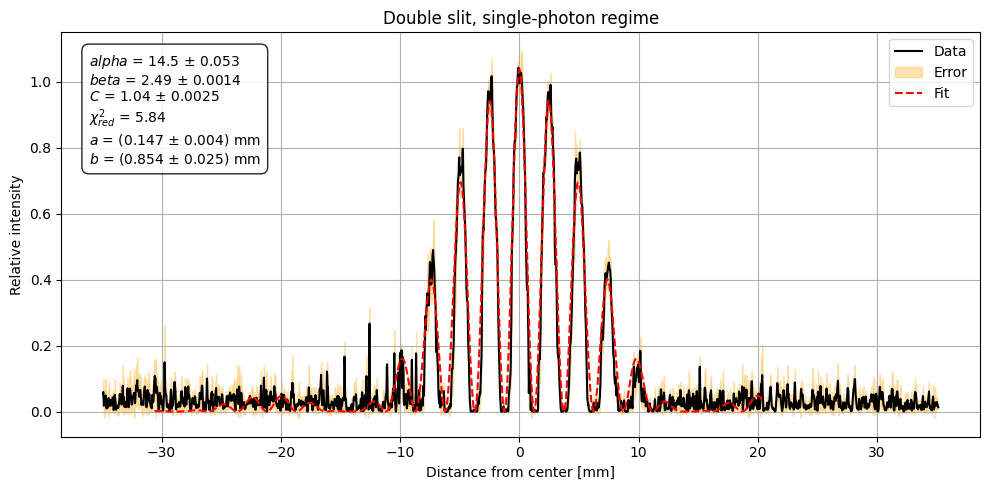

In [2]:
single_photon = analyze_diffraction_image(
    "acquisitions/double-slit-single-photon/pattern.jpg",
    pattern="double",
    pixel_size_mm=0.023350,       # see README for how this was calibrated
    wavelength_nm=520.0, sigma_wavelength_nm=15.0,
    distance_mm=4091.0, sigma_distance_mm=5.0,
)
print(summarize(single_photon))
plot_fit(single_photon, "Double slit, single-photon regime");

Published result (same method, same image, thesis/SIPE25 poster): $a = (0.15 \pm 0.01)$ mm, $b = (0.85 \pm 0.03)$ mm — this rewritten tool reproduces both numbers closely.

## 2. Double slit, high intensity (non-attenuated)

Kentmere Pan 400 film, exposed ~40 s with no strong attenuation, specifically so the fringes would be clearly visible by eye. That deliberate overexposure is the problem for *this* tool: past a certain exposure the film saturates and stops responding linearly to intensity, so the fringe heights near the center flatten out instead of tracing the expected $\operatorname{sinc}^2$ envelope. The fit below is restricted to a $\pm22$ mm window (`fit_window_mm=22`) to stay clear of the worst of the far, non-ideal secondary lobes — but the amplitude-fit method still can't recover a trustworthy slit width $a$ from a saturated image; only the fringe spacing $b$ (which only depends on minima *positions*, not on how tall the peaks are) stays reliable. This is exactly why the original analysis used a different method — fitting a straight line through hand-picked minima positions, insensitive to saturation — for this particular image.

Image: acquisitions/double-slit/pattern.jpg
Pattern: double-slit
  alpha = 49.68 +/- 0.12
  beta = 2.568 +/- 0.00014
  C = 1.277 +/- 0.00085
  reduced chi^2 = 1186.747 (ndof = 887)
Slit width a  = (0.042 +/- 0.001) mm
Slit spacing b = (0.814 +/- 0.024) mm


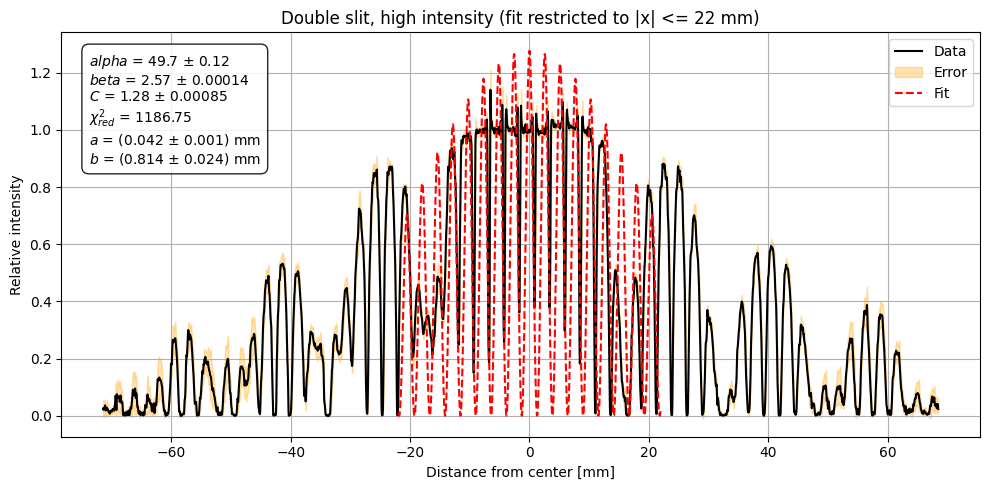

In [3]:
high_intensity = analyze_diffraction_image(
    "acquisitions/double-slit/pattern.jpg",
    pattern="double",
    pixel_size_mm=140 / 3000,     # see README for how this was calibrated
    wavelength_nm=520.0, sigma_wavelength_nm=15.0,
    distance_mm=4021.0, sigma_distance_mm=5.0,
    fit_window_mm=22,
)
print(summarize(high_intensity))
plot_fit(high_intensity, "Double slit, high intensity (fit restricted to |x| <= 22 mm)");

Published result (minima-position method, same image): $a = (0.13 \pm 0.04)$ mm, $b = (0.8 \pm 0.2)$ mm. The fitted spacing $b$ above lands right in that range; the fitted width $a$ does not, for the saturation reason explained above — take $a$ from the single-photon fit or the microscope measurement instead for this experiment.

## 3. Single slit

One of the extra aperture geometries (see the README), shown here just to demonstrate the tool's `pattern="single"` mode (drops the interference term). No independent physical calibration is available for this particular scan, so the result is left in pixels rather than converted to mm — pass `pixel_size_mm` and `distance_mm` on your own images to get a physical slit width out of this mode.

This scan shows the same flat-topped, saturated central lobe as the high-intensity double slit above (it's from the same non-attenuated session), so — as there too — don't trust the fitted `alpha` quantitatively; it's included only to show the fit running on a single-slit pattern, not as a real measurement of this aperture.

Image: acquisitions/single-slit/pattern.jpg
Pattern: single-slit
  alpha = 1264 +/- 1.5
  C = 1.034 +/- 0.00047
  reduced chi^2 = 66.013 (ndof = 2287)


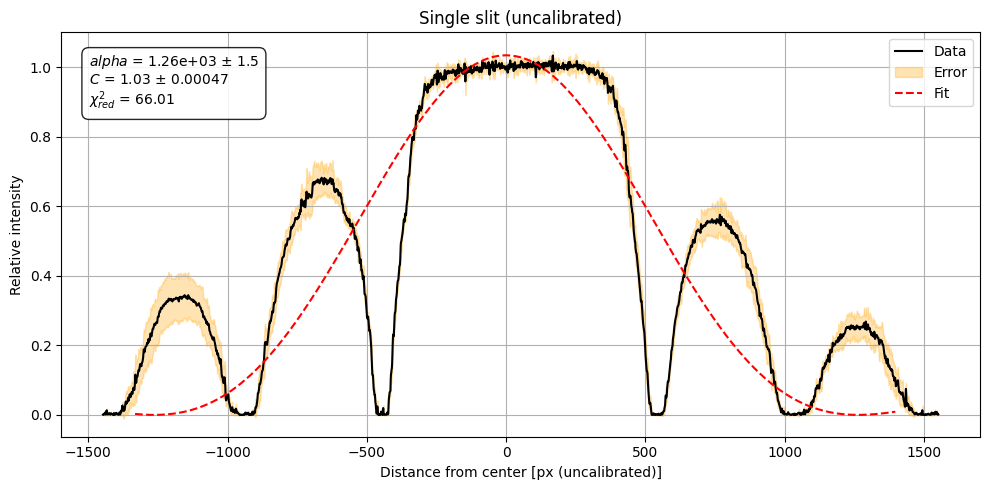

In [4]:
single_slit = analyze_diffraction_image(
    "acquisitions/single-slit/pattern.jpg",
    pattern="single",
)
print(summarize(single_slit))
plot_fit(single_slit, "Single slit (uncalibrated)");

## Using this on your own image

```python
from diffraction_fit import analyze_diffraction_image, summarize, plot_fit

result = analyze_diffraction_image(
    "path/to/your_scan.jpg",
    pattern="double",              # or "single"
    pixel_size_mm=...,             # mm per pixel in your scan
    wavelength_nm=..., sigma_wavelength_nm=...,
    distance_mm=..., sigma_distance_mm=...,
)
print(summarize(result))
plot_fit(result)
```

The center of the pattern and the width of the horizontal band averaged into the intensity profile are auto-detected; pass `center_x_px`, `center_y_px` and/or `band_height_px` explicitly if the auto-detection picks the wrong spot on your image. If the fit visibly latches onto the wrong number of fringes (an occupational hazard of fitting an oscillating function), try `fit_window_mm` to restrict the fit to the cleanest central part of the pattern, or pass your own `p0 = [alpha0, beta0, C0]` (or `[alpha0, C0]` for a single slit).